# Complete End-to-End ML developement Pipeline
This file gives a complete step and end-to-end pipeline of developeing complete ML system. It uses two main ML concepts:
- Clustering
- Sentiment Analysis

The clustering will be developed on youtube comments to understand how data is being scattered. Each clustered will be named by related data it shows regarding different domains and topics. Then sentiment analysis will be trained using two supervised model showing comparisons on which performs best: Logistic Regression or SVC. 

This project's main aim/objective is to find nepalese people's thought on different aspects which could later evolve into a system to track brain-drain, criminal-mindset, sucidal, and more. Overall this project would add some contribution to not only government but also to the citizens by making their voice being heared.

## Data Loading and Splitting
The `go_emotions` data will be loaded and splitted to `train`, `val` and `test`. This will allow us to easily evaluate our model by comparing train vs val curves. The best performing models throught training will be used for evaluation using test set. The yt_comments will not be splitted as they will be used for clustering on KMeans. This is because the data is not labeled on it's sentiment and cannot be evaluated like in supervised learning.

### Import modules
- pandas

Only pandas will be used to split train, test, and validaton set.

In [1]:
import pandas as pd

### Load both the datasets

In [2]:
# load go_emotions
go_emotions = pd.read_csv("./datasets/go_emotions.csv")
# load yt_comments
comments = pd.read_csv("./datasets/yt_comments.csv")

# print shape of both
print(f"Shape of Go Emotions = {go_emotions.shape}")
print(f"Shape of Comments = {comments.shape}")

Shape of Go Emotions = (211201, 29)
Shape of Comments = (19943, 5)


### Split go_emotions into 0.6:0.25:0.15

In [3]:
# calculate size
train_size = int(len(go_emotions) * 0.60)
val_size = train_size + int(len(go_emotions) * 0.25)
test_size = val_size + int(len(go_emotions) * 0.15)

# use size to split
train_emo = go_emotions.iloc[:train_size]
val_emo = go_emotions.iloc[train_size:val_size]
test_emo = go_emotions.iloc[val_size:]

# print all
print(f"Training shape = {train_emo.shape}")
print(f"Validation shape = {val_emo.shape}")
print(f"Testing shape = {test_emo.shape}")

Training shape = (126720, 29)
Validation shape = (52800, 29)
Testing shape = (31681, 29)


# Tokenizations / Embeddings
Two different tokenizers will be used for testing. One will be a basic TF-IDF and another will be a sentence-transformer. These two will be compared to see which one performs better. For KMeans clusters will be evaluated on which created better clusters.

## TF-IDF

First basic TF-IDF will be used. It is not pretrained, and we have two types of dataset:
- Go Emotion with pure english
- Youtube comments showing real concerns with Devnagari, roman nepali and english

So for TF-IDF we would need two seperate vectorizer for each of them if KMeans test gave better results. Some additional cleaning and preprocessing is done before fitting to KMeans for better performance.

### Import library
- TfidfVectorizer from sklearn

This library handles all the calculation required for TF-IDF.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

In [5]:
# CLUSTER TRANSFORMS WITH TEXT PREPROCESSING
custom_stopwords = {
    "sir", "bro", "video", "videos", "thank", "thanks",
    "please", "love", "yo", "dai", "haha", "lol"
}

# regex of number
number_pattern = r'(?u)\b[a-zA-Z]{2,}\b'
# all stop words
all_stopwords = ENGLISH_STOP_WORDS.union(custom_stopwords)
# cluster vectorizer with custom pre-processing
cluster_vectorizer = TfidfVectorizer(
    stop_words=list(all_stopwords),
    max_df=0.8,
    min_df=20,
    ngram_range=(1,2),
    sublinear_tf=True,
    token_pattern=number_pattern
)

en_comment_tfidf = cluster_vectorizer.fit_transform(comments["comment"])

## Sentence-Transformer
Sentence-Trannsformer `allMiniLM` is used for making embeddings. This is a pre-trained encoder transformer which is already able to capture sementic meanings for both english, devnagari and nepali in roman. Therefore, its a powerful alternative to TF-IDF.

### Import Libraries
- SentenceTransformer

In [6]:
from sentence_transformers import SentenceTransformer

c:\Users\tikad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### create a model using `all-MiniLM-l6-v2`

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6493.41it/s]


In [8]:
# ENCODE USING MODEL (NO-FURTHER PRE-PROCESSING)
en_comment_transformer = model.encode(comments["comment"].to_list())

# show shape
print(f"SHAPE OF ENCODED DATA : {en_comment_transformer.shape}")

SHAPE OF ENCODED DATA : (19943, 384)


# KMeans Clustering

Using kMeans clustering on all yt_comments to understand how comments are divided. And visualizing in scatterplot

import required libraries
- KMeans
- matplotlib
- seaborn

KMeans from sklearn will make clusters. Combination of matplotlib and seaborn will be used visualize clustering.

In [9]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

### Reduce Dimension
This will help as TF-IDF creates multiple sparse features and kMeans works well with fewer features

In [10]:
svd = TruncatedSVD(
    n_components=384, # same as sentence-embedding
)

comment_features_tfidf = svd.fit_transform(en_comment_tfidf)

### Fit TF-IDF features on KMeans with 8 clusters

In [11]:
k = 8
# use k means
k_means_tfidf = KMeans(n_clusters=k)
comments["tf_idf_cluster"] = k_means_tfidf.fit_predict(comment_features_tfidf)

In [12]:
pd.set_option("display.max_colwidth", None) # to see full col

# loop to view what each cluster shows
for i in range(k):
    print(f"\nCluster {i}:")
    
    cluster_comments = comments.loc[
        comments["tf_idf_cluster"] == i, "comment"
    ].head(10)

    for comment in cluster_comments:
        print(f"- {comment}")


Cluster 0:
- the review is good but investment is needed to generate income almost every sector is currently running at a loss
- hlo partima dd yek choti oppo reno 16c ko pani review ghardinu na vharkhar vharkhar lunch vako xah india ma oppo reno 16c ko vedio banaunu hunxa vhane aasha ghareko xuh
- amazing review and straight to the point it was a brilliant idea to pick the best iem in every price range and put them together for a comparison next you can do best iems under 5k in 2026
- dd yauta app xa ebay jastai hamrobazar vanne jasma second hand refurbished mobile haru sell hunxa tesko review garnu na
- ani xiaomi 17t ko review khai mero ramari didi xetai halnus haii
- please do review of oppo find x9 s n let us know wether its an upgrade over oppo find x9 pro
- in the review also talk about voice call recording is available or not
- oppo find x 9 ultra vs vivo x300 ultra vs xiaomi 17 ultra review
- pls review and compare the opus op x22 iem with kefine klean sv
- jun phone ko revie

### Evaluation based on cluster texts

- Cluster 0: Mixed unrelated long comments. Grouped mainly because of text length and many words, not topic.
- Cluster 1: Comparison comments ("X is better than Y"). Includes politics and tech, so the topic is mixed.
- Cluster 2: Voting-related comments. A clear and meaningful cluster.
- Cluster 3: Comments about The Nepali Comment channel. Mostly discussion, praise, and criticism.
- Cluster 4: General political complaints. Weak cluster with different issues.
- Cluster 5: Tanka Dahal support/fan comments. Very clear cluster.
- Cluster 6: Random short political comments. Mostly noise.
- Cluster 7: RSP party discussions. Clear political cluster, overlaps with Cluster 2.

### Classify and Visualize
Classifying each clusters accordingly and visualizing using Scatter plot for TF-IDF clusters

In [13]:
tfidf_map = [
    "Mixed",
    "Politics and Tech",
    "Voting",
    "Nepali Comment Channel",
    "Political Complaints",
    "Tanka Dahal Comments",
    "Random Political Chatters",
    "RSP Discussion"
]

comments["tf_idf_cluster"] = comments["tf_idf_cluster"].apply(lambda val: tfidf_map[val])

In [14]:
# dimension reduction from 384 to 2 is needed
svd_two_dim = TruncatedSVD(
    n_components=2, # 2-dimensional
)
# reduced
reduced_features_tfidf = svd_two_dim.fit_transform(comment_features_tfidf)

reduced_tfidf = pd.DataFrame({
    "svd_1":reduced_features_tfidf[:, 0],
    "svd_2":reduced_features_tfidf[:, 1],
    "clusters":comments["tf_idf_cluster"].to_list()
})

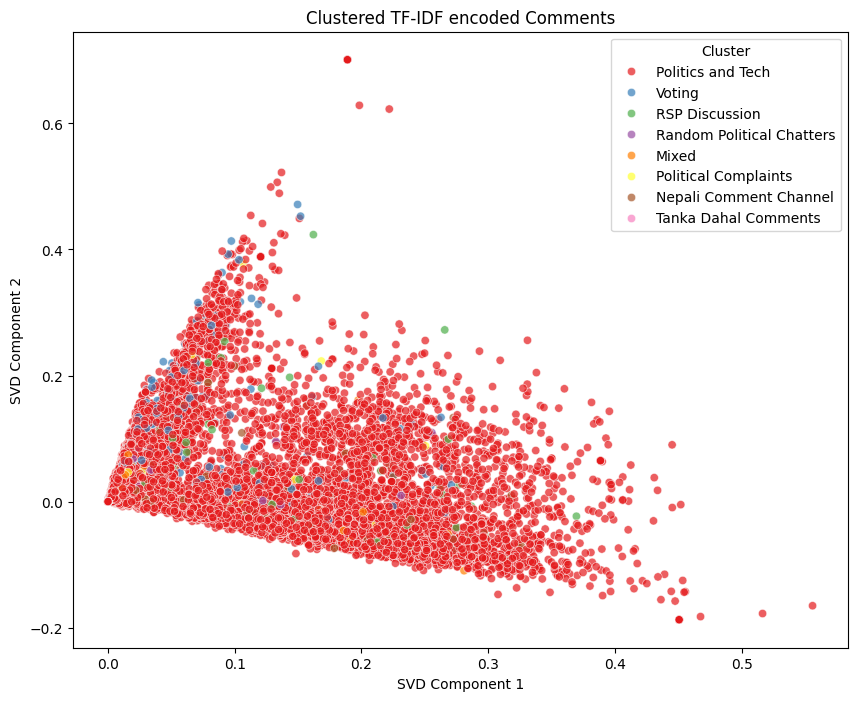

In [15]:
plt.figure(figsize=(10,8)) # Figure canvas size
plt.title("Clustered TF-IDF encoded Comments")# Show title
sns.scatterplot(data=reduced_tfidf, x="svd_1", y="svd_2", palette="Set1", hue="clusters", alpha=0.7)# Show actual scatter plot
plt.xlabel("SVD Component 1")# Show X Label
plt.ylabel("SVD Component 2")# Show Y Label
plt.legend(title="Cluster") # Show actual value for each color
plt.savefig("./experiments/Cluster_TF_IDF_ENCODED_COMMENTS.png") # Save File
plt.show() # Show the plot
plt.close() # Close / Clean Memory

### Fit All-MiniLM-L6-v2 encoded features on KNN

In [17]:
# use k means
k_means_st = KMeans(n_clusters=k)
comments["st_cluster"] = k_means_st.fit_predict(en_comment_transformer)

In [18]:
# loop to view what each cluster shows
for i in range(k):
    print(f"\nCluster {i}:")
    
    cluster_comments = comments.loc[
        comments["st_cluster"] == i, "comment"
    ].head(10)

    for comment in cluster_comments:
        print(f"- {comment}")


Cluster 0:
- माननीय प्रधानमन्त्रीज्यू नमस्कार। राष्ट्रको नेतृत्व गर्ने व्यक्तिको प्रत्येक अभिव्यक्ति केवल व्यक्तिगत विचार हुँदैन त्यसले देशको कूटनीति राष्ट्रिय भावना र अन्तर्राष्ट्रिय सम्बन्धमा समेत प्रभाव पार्ने गर्दछ। हालै तपाईंबाट व्यक्त भएका केही भनाइहरूले देशभित्र व्यापक बहस विवाद र जिज्ञासा सिर्जना गरेको देखिएको छ। नेपालको इतिहास सीमा राष्ट्रिय स्वाभिमान र भूराजनीतिक संवेदनशीलतासँग सम्बन्धित विषयहरूमा बोल्दा शब्दहरूको तौल निकै ठूलो हुन्छ। जनताले आफ्ना नेताबाट स्पष्टता दूरदृष्टि र राष्ट्रिय हितप्रतिको दृढ प्रतिबद्धता अपेक्षा गर्छन्। हामी इतिहासलाई भावनाले मात्र होइन तथ्य प्रमाण र कूटनीतिक संवादका आधारमा हेर्न चाहन्छौँ। राष्ट्रिय मुद्दाहरूमा राजनीतिक मतभेद हुन सक्छन् तर राष्ट्रिय स्वाभिमान र सार्वभौमिकताको प्रश्नमा सम्पूर्ण नेपाली एकजुट हुन आवश्यक छ। आज नेपाली युवाहरूको प्रश्न सरल छ नेपालको भूमि इतिहास र राष्ट्रिय हितका विषयमा सरकारको स्पष्ट धारणा के हो हामी आशा गर्दछौँ कि सरकार राष्ट्रिय हितलाई सर्वोपरि राख्दै छिमेकी राष्ट्रहरूसँगको सम्बन्धलाई सम्मान समानता र कूटनीतिक परिपक्वताका

### Classify and Visualize
Classifying each clusters accordingly and visualizing using Scatter plot for Sentence-Transformer clusters

In [19]:
tfidf_map = [
    "Mixed",
    "Politics and Tech",
    "Voting",
    "Nepali Comment Channel",
    "Political Complaints",
    "Tanka Dahal Comments",
    "Random Political Chatters",
    "RSP Discussion"
]

comments["st_cluster"] = comments["st_cluster"].apply(lambda val: tfidf_map[val])